# ECE1508: Deep Generative Models -- Summer 2026
## Assignment 4: Variational Inference and VAEs
## Question 2: Variational Inference with Gaussian Data

In this question, we use variational inference to learn distribution of a Gaussian data via a simple linear model. This question is closely related to Practice Question 1. 

We consider Gaussian synthetic data generated from the marginal distribution
$$
x \sim \mathcal{N}(0, 1.25).
$$

To learn this distribution, we consider a probabilistic generator which samples latent as
$
z \sim \mathcal{N}(0,1),
$
and then generates data sample conditionally as
$$
x \sim \mathcal{N}(\theta z, 1),
$$
for some learnable $\theta$.

Following Practice Question 1 in the assignment, it is easy to see that the optimal choice of $\theta$ is $\theta^\star = 0.5$ which matches the generator distribution to the true data distribution.

## Question: _Explain why the optimal model parameter is $\theta^\star=0.5$?_
 Since $x=\theta z+\varepsilon$ with $z,\varepsilon\sim\mathcal N(0,1)$ independent, the model's marginal is $x\sim\mathcal N(0,\theta^2+1)$. Matching this to the true data distribution $\mathcal N(0,1.25)$ gives $\theta^2+1=1.25$, i.e. $\theta^\star=0.5$.

### Loading Modules

In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Let's have high accuracy
torch.set_default_dtype(torch.float64)

# To reproduce later
torch.manual_seed(0)
np.random.seed(0)

# Let's keep it on CPU as it is a very simple task
device = torch.device("cpu")

### Synthetic Data Generation
We now generate data according to 
$
x \sim \mathcal{N}(0, 1.25),
$
and estimate its mean and variance from the data samples.

In [2]:
# Synthetic Data
n_data = int(1e4)
true_mean = 0
true_var = 1.25

# True value of theta, i.e., theta^*
true_theta = math.sqrt(true_var - 1) # 0.5

# Generate dataset
x_data = torch.randn(n_data) * math.sqrt(true_var) + true_mean

# Print True Values and Estimators
print(f"True Mean: {true_mean:.3f}")
print(f"Sample Mean Estimator: {x_data.mean().item():.4f}")

print(f"True Variance: {true_var:.3f}")
print(f"Sample Variance Estimator: {x_data.var(unbiased=True).item():.4f}")

True Mean: 0.000
Sample Mean Estimator: -0.0223
True Variance: 1.250
Sample Variance Estimator: 1.2683


#### Histogram
Let's take a look at dataset histogram

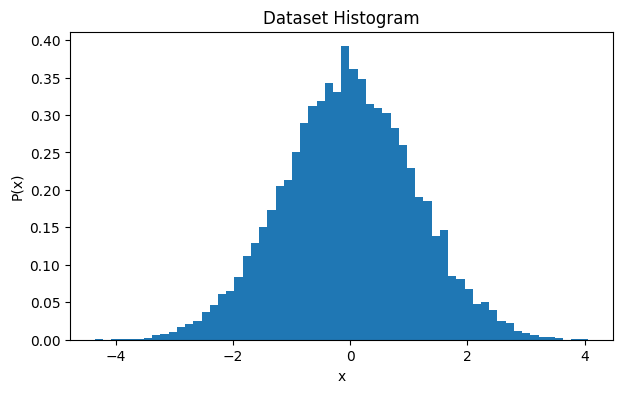

In [3]:
# Plot the histogram of dataset x_data
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(x_data.numpy(), bins=60, density=True)
ax.set_title("Dataset Histogram")
ax.set_xlabel("x")
ax.set_ylabel("P(x)")
plt.show()

### Implement the Model and Visualize Its Distribution
Let us now implement the probabilistic generator and visualize its distribution for an arbitrary choice of $\theta$. 

In [4]:
# Define log-density of a Gaussian with <mean> and <var>
def log_normal_pdf(x, mean, var):
    return -0.5 * (math.log(2.0 * np.pi) + math.log(var) + (x - mean) ** 2 / var)

# Define density of a Gaussian with <mean> and <var>
def normal_pdf(x, mean, var):
    return torch.exp(log_normal_pdf(x, mean, var))

# Define the probabilistic generator which samples z and then x conditional to z
def generator(theta, n_samples):
    # Sample from latent z ~ N(0,1)
    z = torch.randn(n_samples)

    # Sample x conditional to z 
    x = theta * z + torch.randn(n_samples)
    return z, x

# Define the mean and variance of the model distribution P_\theta(x)
# You may use the results of Question 1
def model_params(theta):
    var_model = theta**2 + 1
    mean_model = 0.0
    return mean_model, var_model

# Define the mean and variance of the posterior distribution P_\theta(z|x)
# You may use the results of Question 1
def posterior_params(x, theta):
    var_post = 1.0 / (1.0 + theta**2)
    mean_post = var_post * theta * x
    return mean_post, var_post

We can now sample the model at different values of $\theta$ and compare model and data distributions.

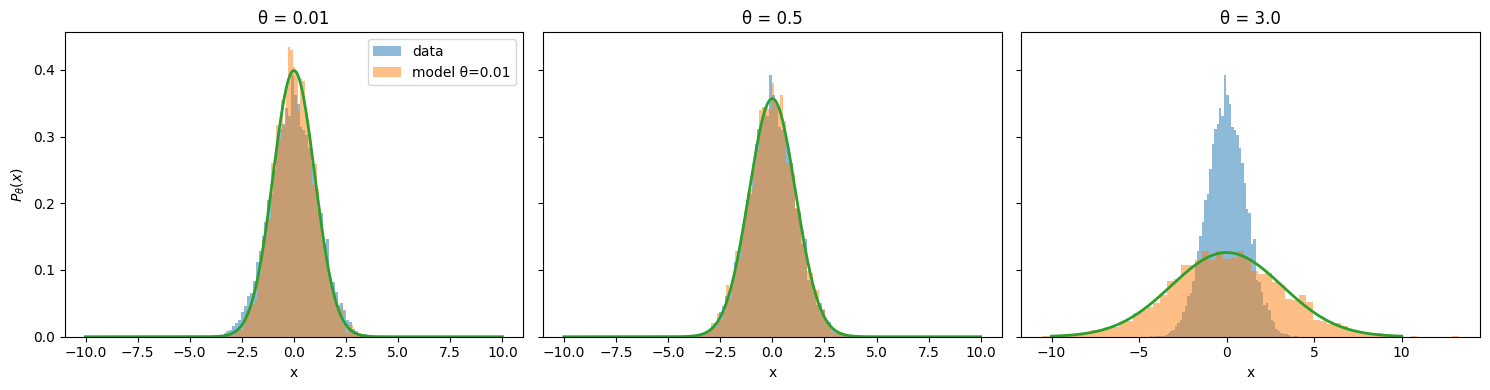

In [5]:
# Consider a list of three theta values.
theta_list = [0.01, 0.5, 3.0]
# Set number of samples taken from the model.
n_samples= 5000

fig, axes = plt.subplots(1, len(theta_list), figsize=(15, 4), sharey=True)

# Loop over theta list
for ax, theta in zip(axes, theta_list):
    # Sample generator for n_samples times
    _, x_samples = generator(theta, n_samples)

    # Plot the model histogram and compare against data
    ax.hist(x_data.numpy(), bins=60, density=True, alpha=0.5, label="data")
    ax.hist(x_samples.numpy(), bins=60, density=True, alpha=0.5, label=f"model θ={theta}")

    # Also plot the PDF of model to compare it against its histogram
    xs = torch.linspace(-10, 10, 1000)
    mean_model, var_model = model_params(theta)
    ax.plot(xs.numpy(), normal_pdf(xs, mean_model, var_model).numpy(), linewidth=2)
    ax.set_title(f"θ = {theta}")
    ax.set_xlabel("x")

axes[0].set_ylabel("$P_θ (x)$")
axes[0].legend()
plt.tight_layout()
plt.show()

## Question: _At which $\theta$ the model matches data histogram? Does that make sense? Explain your observation._  
$\theta = 0.5$ is the one who matches the data histogram. This makes sense because we derived $\theta=0.5$ exactly by matching the model's marginal variance $\theta^2+1$ to the true data variance. 


### Direct Estimate of Model Distribution via Monte Carlo Method
We know examine direct estimation of the evidence via Monte Carlo and take a look at its variance.

In [6]:
# Estimate P_theta(x) = E_{z~P(z)}[P_theta(x|z)] by Monte Carlo
def mc_evidence_estimate(x, theta, n_samples, seed):

    # sample n_samples samples from P(z)
    g = torch.Generator().manual_seed(seed)
    z_samples = torch.randn(n_samples)

    # Compute MC Estimate
    likelihoods = normal_pdf(x, theta * z_samples, 1.0)
    return likelihoods.mean()

# Fix the observation to the first data sample
x0 = x_data[0].clone()

# Set a theta
theta = 0.5
mean_model, var_model = model_params(theta)

# Print exact evidence
print(f"Sample x ={x0}")
print(f"Exact Evidence P_theta (x) = {normal_pdf(x0, mean_model, var_model)}")

Sample x =-2.5831189206706417
Exact Evidence P_theta (x) = 0.024735603098843803


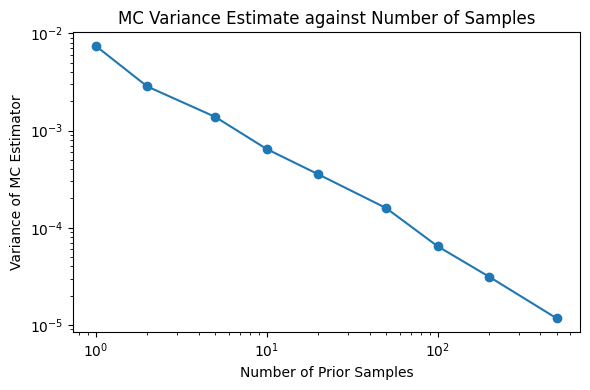

In [7]:
# Compute mean and variance of MC estimate with <n_samples> from <n_seeds> different seeds
def repeat_mc_estimate(x, theta, n_samples, n_seeds=100, seed_str = 998):
    estimates = torch.tensor([
        mc_evidence_estimate(x, theta, n_samples, seed=seed_str + i)
        for i in range(n_seeds)
    ])
    return estimates.mean().item(), estimates.var(unbiased=True).item()


# Set some theta
theta = 1

# List of number of samples and loop over it
n_grid = [1, 2, 5, 10, 20, 50, 100, 200, 500]

mc_means = []
mc_vars = []
for n_samples in n_grid:
    mc_mean, mc_var = repeat_mc_estimate(x0, theta, n_samples)
    mc_means.append(mc_mean)
    mc_vars.append(mc_var)

# Plot the mean estimates and their variances
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n_grid, mc_vars, marker="o")
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Number of Prior Samples")
ax.set_ylabel("Variance of MC Estimator")
ax.set_title("MC Variance Estimate against Number of Samples")
plt.tight_layout()
plt.show()


### Estimate Evidence by ELBO Maximization
We now use ELBO maximization and importance sampling to estimate the evidence. The following code implements optimization of $Q(\alpha, \beta^2)$ for $\alpha$ and $\beta$ maximizing the ELBO. 

In [8]:
# Monte Carlo ELBO estimate 
# Assume the model Q(z|x) = N(alpha, beta^2).
def elbo_mc(x, theta, alpha, log_beta, n_mc=1):
    # Maybe easier to work with log beta and compute beta as toch.exp(log_beta)
    # this would be numerically more stable
    beta = torch.exp(log_beta)
    eps = torch.randn(n_mc)
    z = alpha + beta * eps

    log_p_x_given_z = log_normal_pdf(x, theta * z, 1.0)
    log_p_z = log_normal_pdf(z, 0.0, 1.0)
    log_q_z_given_x = log_normal_pdf(z, alpha, beta ** 2)

    return (log_p_x_given_z + log_p_z - log_q_z_given_x).mean()


# Loop over Q to optimize it for K iterations of SGD
def train_Q(x, theta, K=200, lr=5e-2, n_mc=1, alpha0=0.0, log_beta0=-0.1):
    # initiate alpha and beta
    alpha = torch.nn.Parameter(torch.tensor(float(alpha0), device=device))
    log_beta = torch.nn.Parameter(torch.tensor(float(log_beta0), device=device))
    opt = torch.optim.Adam([alpha, log_beta], lr=lr)


    elbo_hist = []
    # Train for K iterations
    for k in range(K):
        opt.zero_grad()
        elbo = elbo_mc(x, theta, alpha, log_beta, n_mc)
        loss = -elbo
        loss.backward()
        opt.step()
        elbo_hist.append(elbo.item())

    beta = torch.exp(log_beta)
    return {
        "alpha": alpha.item(),
        "beta": beta.item(),
        "elbo_hist": elbo_hist,
        "alpha_tensor": alpha.detach(),
        "log_beta_tensor": log_beta.detach(),
    }

#### Comparing to Posterior
Let us know train $Q$ and compare it against the posterior.

learned mean for Q = -1.298982630740042
posterior mean = -1.2915594603353209
learned standard deviation for Q  = 0.10687110138007135
posterior standard deviation  = 0.7071067811865476


/var/folders/4f/yqk707nn61d0n9l9qmlg7f4w0000gn/T/ipykernel_15352/1897220206.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return -0.5 * (math.log(2.0 * np.pi) + math.log(var) + (x - mean) ** 2 / var)


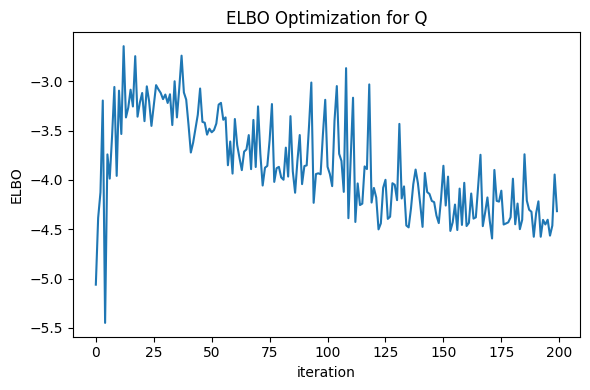

In [9]:
# Let's consider one model value
theta = 1

# Optimize Q for 200 iterations with batches of size <n_mc=5>
Q = train_Q(x0, theta, n_mc=5)

# Print the posterior mean and variance at the exact same sample x0 for comparison
mean_post, var_post = posterior_params(x0, theta)
print("learned mean for Q =", Q["alpha"])
print("posterior mean =", float(mean_post))

print("learned standard deviation for Q  =", Q["beta"])
print("posterior standard deviation  =", float(var_post) ** 0.5)

# Let's take a look at the training curve
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Q["elbo_hist"])
ax.set_xlabel("iteration")
ax.set_ylabel("ELBO")
ax.set_title("ELBO Optimization for Q")
plt.tight_layout()
plt.show()

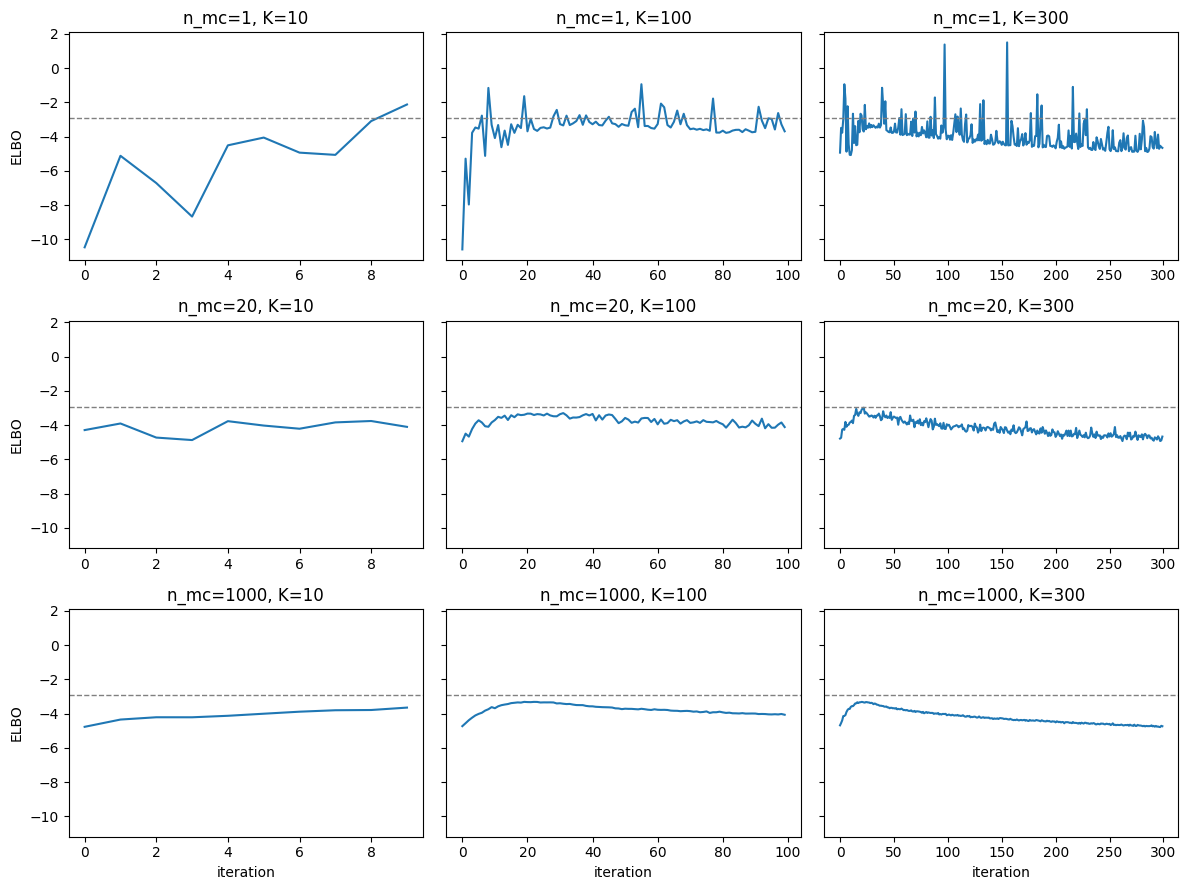

In [10]:
# 3 by 3 subplots with different n_mc and K

theta = 1

# Reference: true log-evidence at x0 for this theta
log_evidence = math.log(float(normal_pdf(x0, *model_params(theta))))

n_mc_list = [1, 20, 1000]
K_list = [10, 100, 300]

fig, axes = plt.subplots(len(n_mc_list), len(K_list), figsize=(12, 9), sharey=True)

for i, n_mc in enumerate(n_mc_list):
    for j, K in enumerate(K_list):
        ax = axes[i, j]
        Q = train_Q(x0, theta, K=K, n_mc=n_mc)

        ax.plot(Q["elbo_hist"])
        ax.axhline(log_evidence, color="gray", linestyle="--", linewidth=1)
        ax.set_title(f"n_mc={n_mc}, K={K}")

        if i == len(n_mc_list) - 1:
            ax.set_xlabel("iteration")
        if j == 0:
            ax.set_ylabel("ELBO")

plt.tight_layout()
plt.show()

## Question: _What is the converging distribution? Explain your observation. Examine your findings for various choices of `n_mc` between 1 and 1000 and `K` between 10 and 300. How sensitive is the final Q to these parameters?_
The converging distribution is the true posterior $P_\theta(z|x_0)$. According to this 3x3 subplots with various n_mc and K, when n_mc gets larger and K gets smaller, the trend gets smoother, just like the bottom left plot. As opposed to top right, with n_mc = 1 and K = 300, it fluctuates the most. 

#### Estimate Evidence via Importance Sampling with Learned $Q$
We now use the learned $Q$ to estimate the evidence and compare it against the direct MC estimate.

In [11]:
# Estimate P_theta(x) via importance sampling using Q(z|x) = N(alpha,beta^2)
def importance_sampling_estimate(x, theta, alpha, beta, n_samples):
    ## COMPLETE ##
    z = alpha + beta * torch.randn(n_samples)
    log_w = (log_normal_pdf(x, theta * z, 1.0) + log_normal_pdf(z, 0.0, 1.0) - log_normal_pdf(z, alpha, beta ** 2))
    return torch.exp(log_w).mean()


# Compute Mean and variance of Importance Sampling estimator 
def repeat_imp_samp_estimate(x, theta, alpha, beta, n_samples, n_seeds=100, seed_str = 998):
    ## COMPLETE ##
    estimates = []
    for i in range(n_seeds):
        g = torch.Generator().manual_seed(seed_str + i)
        z = alpha + beta * torch.randn(n_samples, generator=g)
        log_w = (log_normal_pdf(x, theta * z, 1.0) + log_normal_pdf(z, 0.0, 1.0) - log_normal_pdf(z, alpha, beta ** 2))
        estimates.append(torch.exp(log_w).mean())
    estimates = torch.stack(estimates)
    return estimates.mean().item(), estimates.var(unbiased=True).item()


# Let's take a look at an example
theta = 1
alpha = Q["alpha"]
beta = Q["beta"]
n_samples = 5
# mean, var = ## COMPLETE ##
mean, var = repeat_imp_samp_estimate(x0, theta, alpha, beta, n_samples)
print(f"mean = {mean} | variance = {var}")

mean = 0.013615451870195909 | variance = 0.00015761161623063723


#### Plot Variance against $K$ and Number of Samples
We now plot the variance of importance sampling estimate to compare it against the MC estimate.

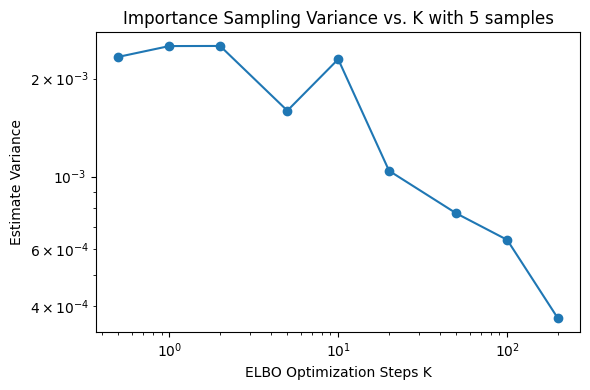

In [12]:
# Set the model to that of MC estimate
theta = 1

# Plot variance of importance sampling estimate against K
K_grid = [0, 1, 2, 5, 10, 20, 50, 100, 200]
n_samples = 5 # Note that this is significantly small!!

# Loop over K
est_vars = []
est_means = []
alphas = []
betas = []

for K in K_grid:
    ## COMPLETE ##
    Qk = train_Q(x0, theta, K=K, n_mc=5)
    m, v = repeat_imp_samp_estimate(x0, theta, Qk["alpha"], Qk["beta"], n_samples)
    est_means.append(m)
    est_vars.append(v)
    alphas.append(Qk["alpha"])
    betas.append(Qk["beta"])

# Plot variance against K
fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xscale("log")
ax.set_yscale("log")

## COMPLETE ##
ax.plot([max(k, 0.5) for k in K_grid], est_vars, marker="o")

ax.set_xlabel("ELBO Optimization Steps K")
ax.set_ylabel("Estimate Variance")
ax.set_title(f"Importance Sampling Variance vs. K with {n_samples} samples")
plt.tight_layout()
plt.show()


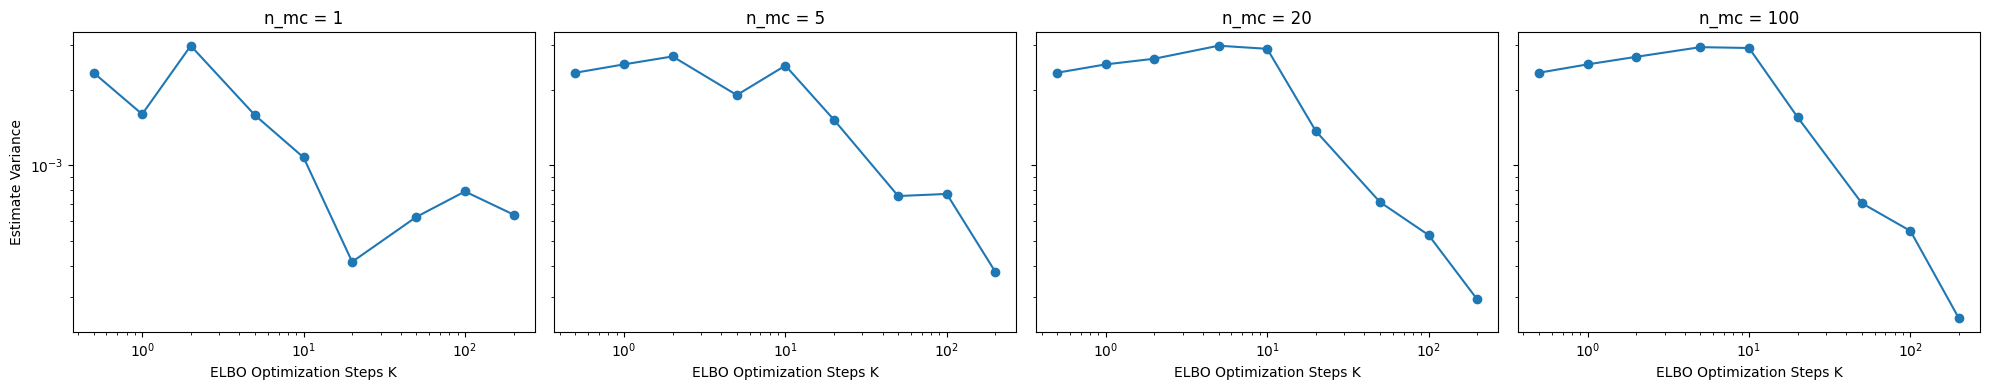

In [13]:
# to play with different n_mc

theta = 1
K_grid = [0, 1, 2, 5, 10, 20, 50, 100, 200]
n_samples = 5  # Note that this is significantly small!!

n_mc_list = [1, 5, 20, 100]

fig, axes = plt.subplots(1, len(n_mc_list), figsize=(5 * len(n_mc_list), 4), sharey=True)

for ax, n_mc in zip(axes, n_mc_list):
    est_vars = []
    for K in K_grid:
        Qk = train_Q(x0, theta, K=K, n_mc=n_mc)
        _, v = repeat_imp_samp_estimate(x0, theta, Qk["alpha"], Qk["beta"], n_samples)
        est_vars.append(v)

    ax.plot([max(k, 0.5) for k in K_grid], est_vars, marker="o")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("ELBO Optimization Steps K")
    ax.set_title(f"n_mc = {n_mc}")

axes[0].set_ylabel("Estimate Variance")
plt.tight_layout()
plt.show()

## Question: _Considering the above curve, what do you conclude about a favorable choice of $K$? Play with `n_mc` in `train_Q` and explain your observation._
A favourable choice of K can be picked at whenever teh curve first flattens, with diminishing returns beyond that point. On the subplots with different n_mc above, K=10 seems to be a good choice. 

Next we plot the variance against the number of samples used for estimation.

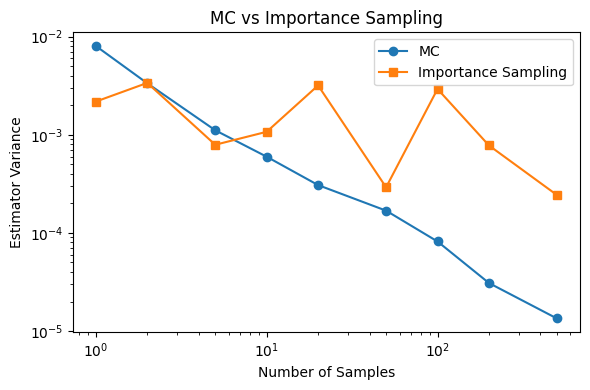

In [14]:
# Set K and train Q
K = 50
theta = 1
Q = train_Q(x0, theta, K=K, n_mc=4)

## COMPLETE ##
alpha_learned = Q['alpha']
beta_learned = Q['beta']

# List numbers of samples and loop over them
# We also compute MC estimate variances for comparison
n_grid = [1, 2, 5, 10, 20, 50, 100, 200, 500]
ImpSamp_vars = []
MC_vars = []

for n_samples in n_grid:
   ## COMPLETE ##
   _, v_is = repeat_imp_samp_estimate(x0, theta, alpha_learned, beta_learned, n_samples)
   _, v_mc = repeat_mc_estimate(x0, theta, n_samples)
   ImpSamp_vars.append(v_is)
   MC_vars.append(v_mc)


# Plot the variances
fig, ax = plt.subplots(figsize=(6, 4))

## COMPLETE ##
ax.plot(n_grid, MC_vars, marker="o", label="MC")
ax.plot(n_grid, ImpSamp_vars, marker="s", label="Importance Sampling")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Number of Samples")
ax.set_ylabel("Estimator Variance")
ax.set_title("MC vs Importance Sampling")
ax.legend()
plt.tight_layout()
plt.show()

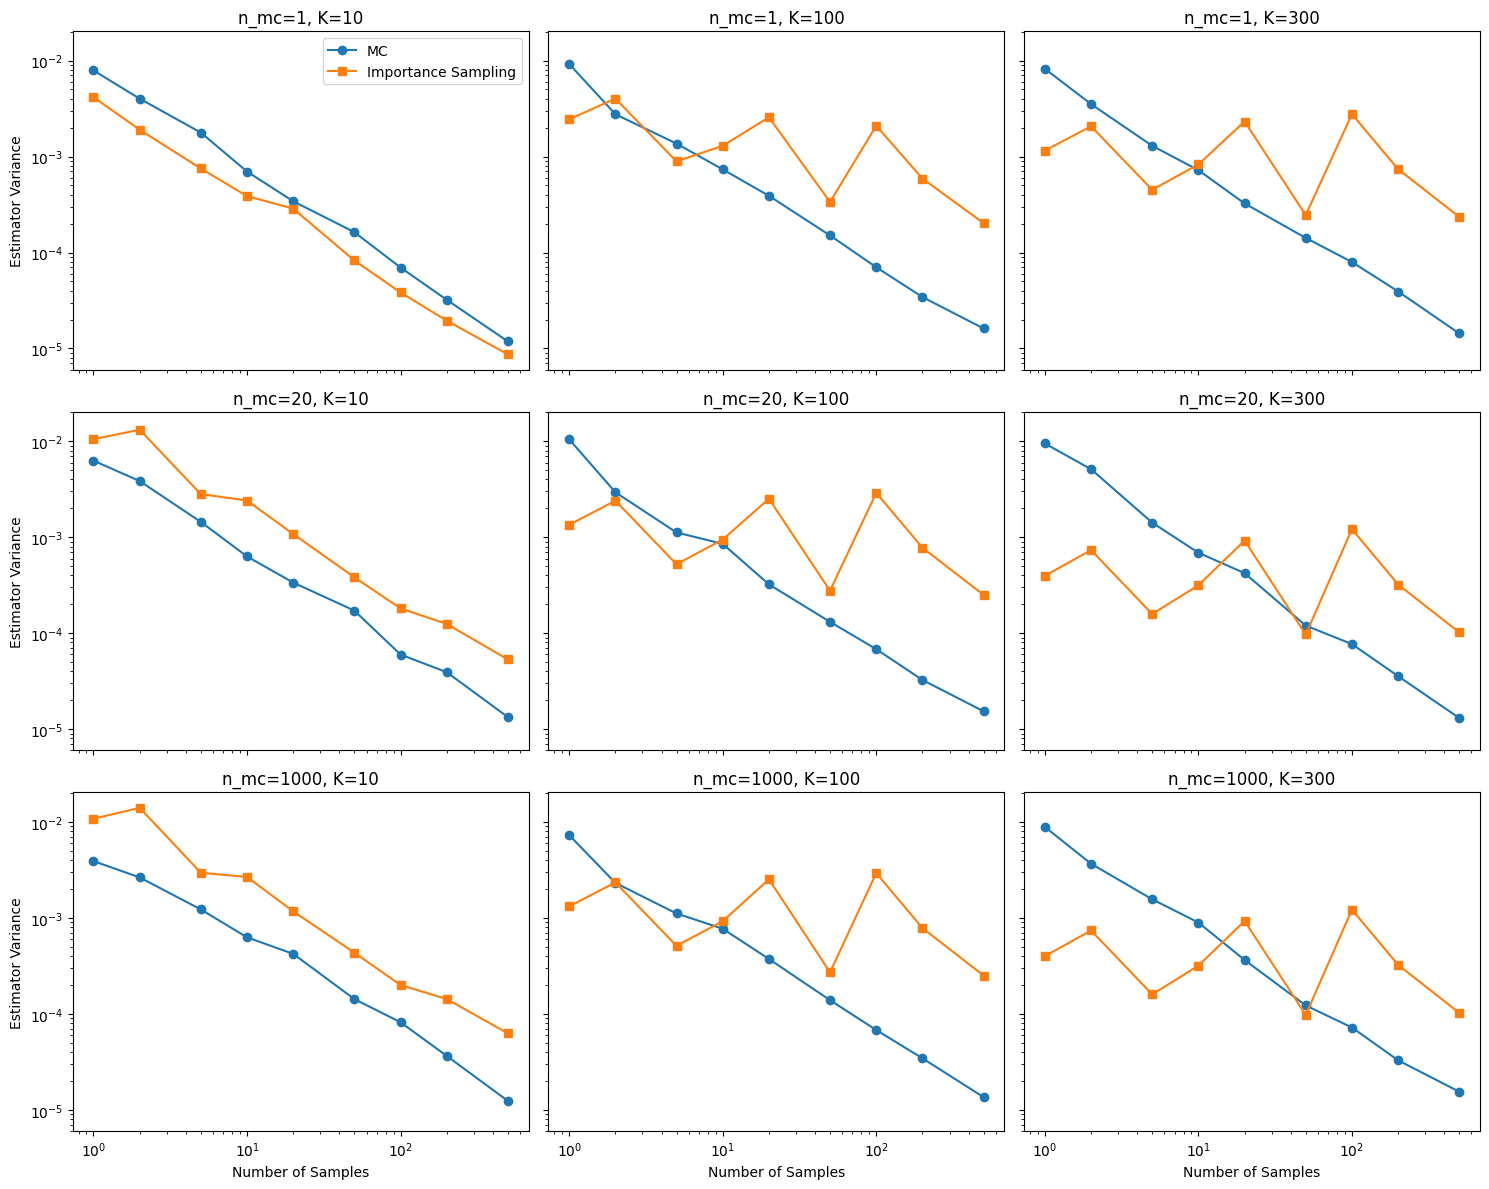

In [15]:
theta = 1
n_grid = [1, 2, 5, 10, 20, 50, 100, 200, 500]

n_mc_list = [1, 20, 1000]
K_list = [10, 100, 300]

fig, axes = plt.subplots(len(n_mc_list), len(K_list), figsize=(15, 12), sharex=True, sharey=True)

for i, n_mc in enumerate(n_mc_list):
    for j, K in enumerate(K_list):
        ax = axes[i, j]
        Q = train_Q(x0, theta, K=K, n_mc=n_mc)
        alpha_learned, beta_learned = Q["alpha"], Q["beta"]

        ImpSamp_vars, MC_vars = [], []
        for n_samples in n_grid:
            _, v_is = repeat_imp_samp_estimate(x0, theta, alpha_learned, beta_learned, n_samples)
            _, v_mc = repeat_mc_estimate(x0, theta, n_samples)
            ImpSamp_vars.append(v_is)
            MC_vars.append(v_mc)

        ax.plot(n_grid, MC_vars, marker="o", label="MC")
        ax.plot(n_grid, ImpSamp_vars, marker="s", label="Importance Sampling")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(f"n_mc={n_mc}, K={K}")

for ax in axes[-1, :]:
    ax.set_xlabel("Number of Samples")
for ax in axes[:, 0]:
    ax.set_ylabel("Estimator Variance")

axes[0, 0].legend()
plt.tight_layout()
plt.show()

## Question: _Play with `n_mc` in `train_Q` and `K`. Explain your observation._
With K=10, both MC and Importance Sampling almost follow the same trend; when K increases, MC would not change much but Importance Sampling would start to fluctuate. 

## Question: _What do you conclude from comparing MC and Importance Sampling? Does it match your initial intuition?_
_## COMPLETE ##_